<a href="https://colab.research.google.com/github/sachint19004/telco-churn-roi-optimization/blob/main/Customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

filepath

In [ ]:
file_path = '/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

clean the data

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

generate EDA Visualizations

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

Churn vs. Contract Type

Text(0.5, 1.0, 'Churn by Contract Type')

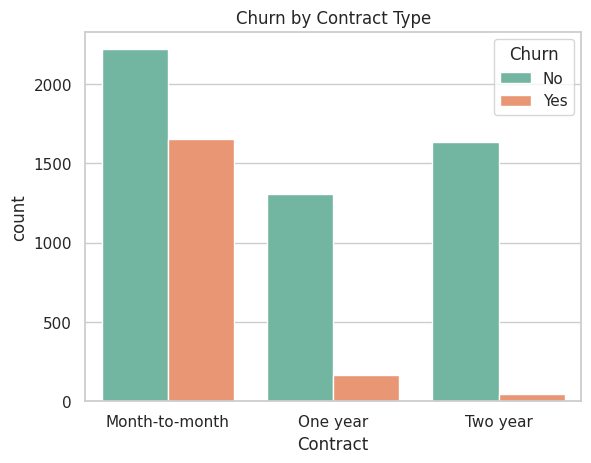

In [ ]:
plt.subplot(1, 1, 1)
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Contract Type')

Churn vs. Tenure

Text(0.5, 1.0, 'Churn by Tenure (Months)')

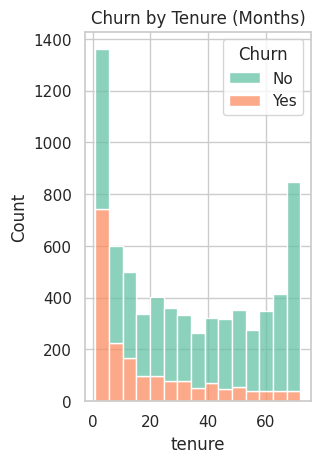

In [ ]:
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='tenure', hue='Churn', multiple="stack", palette='Set2')
plt.title('Churn by Tenure (Months)')

Churn vs. Monthly Charges

Text(0.5, 1.0, 'Churn by Monthly Charges')

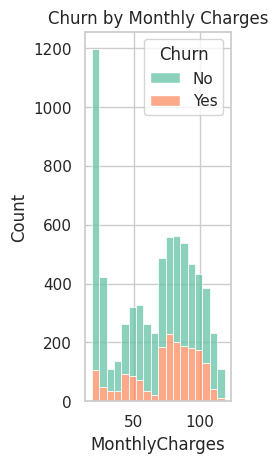

In [ ]:
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple="stack", palette='Set2')
plt.title('Churn by Monthly Charges')

In [ ]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

Statistics

In [ ]:
from scipy.stats import chi2_contingency

# 1. Create a Contingency Table (Grid of Contract vs. Churn)
contingency_table = pd.crosstab(df['Contract'], df['Churn'])
print("--- Contingency Table ---")
print(contingency_table)
print("\n")

# 2. Run the Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# 3. Print the result like a Data Scientist
print(f"P-Value: {p_value}")

if p_value < 0.05:
    print("Conclusion: STATISTICALLY SIGNIFICANT! The CEO needs to know: Contract type definitively impacts Churn.")
else:
    print("Conclusion: Not Significant. It might just be random noise.")

--- Contingency Table ---
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48


P-Value: 7.326182186265472e-257
Conclusion: STATISTICALLY SIGNIFICANT! The CEO needs to know: Contract type definitively impacts Churn.


Training AI MODEL

Training the AI Model... Please wait...



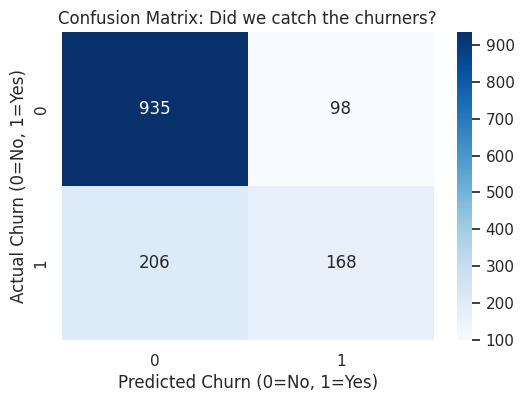


--- AI Final Exam Report ---
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.45      0.53       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare Data: Drop useless ID column & turn text into numbers
X = pd.get_dummies(df.drop(['customerID', 'Churn'], axis=1), drop_first=True)
# Convert 'Yes'/'No' churn into 1 and 0
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Train/Test Split: 80% for studying, 20% for the final exam
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Random Forest Model
print("Training the AI Model... Please wait...\n")
model = RandomForestClassifier(n_estimators=100,class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 4. Give the Model the Final Exam
predictions = model.predict(X_test)

# 5. Show the Results (Confusion Matrix & Report)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Did we catch the churners?')
plt.ylabel('Actual Churn (0=No, 1=Yes)')
plt.xlabel('Predicted Churn (0=No, 1=Yes)')
plt.show()

print("\n--- AI Final Exam Report ---")
print(classification_report(y_test, predictions))

ROI

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# 1. Re-prepare data including our brand new feature
df['Charges_Per_Month_Of_Loyalty'] = df['MonthlyCharges'] / (df['tenure'] + 1)
X = pd.get_dummies(df.drop(['customerID', 'Churn'], axis=1), drop_first=True)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train model WITH class balancing
model_optimized = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_optimized.fit(X_train, y_train)

# 4. Instead of basic predict, get the exact raw probabilities (percentages)
predicted_probabilities = model_optimized.predict_proba(X_test)[:, 1]

# 5. Apply our strict 65% business confidence threshold
custom_threshold = 0.65
predictions_optimized = (predicted_probabilities >= custom_threshold).astype(int)

# 6. ROI Calculator Function
def calculate_model_roi(y_true, y_pred, monthly_revenue=50, discount_cost=15, success_rate=0.5):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    revenue_saved = tp * success_rate * monthly_revenue
    discount_cost_total = (tp + fp) * discount_cost
    net_roi = revenue_saved - discount_cost_total

    print("=== OPTIMIZED HIGH-ROI FINANCIAL REPORT ===")
    print(f"False Positives (Wasted Discounts): {fp} (Dropped significantly!)")
    print(f"Total Customers Saved: {int(tp * success_rate)}")
    print(f"Gross Revenue Preserved: ${revenue_saved:,}")
    print(f"Total Campaign Cost: ${discount_cost_total:,}")
    print(f"Net Monthly Model Value: ${net_roi:,}")

# Run it!
calculate_model_roi(y_test, predictions_optimized)

=== OPTIMIZED HIGH-ROI FINANCIAL REPORT ===
False Positives (Wasted Discounts): 40 (Dropped significantly!)
Total Customers Saved: 56
Gross Revenue Preserved: $2,800.0
Total Campaign Cost: $2,280
Net Monthly Model Value: $520.0


In [ ]:
df['Charges_Per_Month_Of_Loyalty'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# 2. Explicitly print the first 5 rows to see your creation!
print(df[['MonthlyCharges', 'tenure', 'Charges_Per_Month_Of_Loyalty']].head())

   MonthlyCharges  tenure  Charges_Per_Month_Of_Loyalty
0           29.85       1                     14.925000
1           56.95      34                      1.627143
2           53.85       2                     17.950000
3           42.30      45                      0.919565
4           70.70       2                     23.566667
